In [1]:
import os, json, joblib, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
os.makedirs('artifacts', exist_ok=True)

Device: cuda


In [3]:
CFG = dict(
    # Data
    window_size   = 60,
    horizon      = 5,
    train_frac    = 0.70,
    val_frac      = 0.15,

    # Feature engineering
    roll_window   = 10,
    lag_steps     = [1, 3, 5],

    # Shared training defaults
    batch_size      = 128,
    max_epochs      = 100,
    label_smoothing = 0.5,

    # Class weighting
    minority_boost_classes = ['CALL_DROP', 'CAPACITY_EXHAUSTED'],
    lr                    = 5e-5,  # was 1e-4 — slightly lower, best at ep=1 means LR slightly high
    hidden_size           = 256,
    num_layers            = 2,
    dropout               = 0.35,  # was 0.4 — slightly more regularisation
    patience              = 12,
    transition_oversample = 6,
    minority_boost        = 1.0,   # was 1.3 — precision=0.44 still too low, reduce boost
    focal_gamma           = 1.5,
    clip_grad             = 0.5,
    weight_decay          = 3e-3,

)


In [4]:
LOCAL_PATH = './data/network_qoe_latest.csv'
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PATH = '/content/drive/MyDrive/network_qoe_latestin.csv'
except Exception:
    PATH = LOCAL_PATH

df_raw = pd.read_csv(PATH)
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], unit='s')
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (152071, 33)


,run_id,timestamp,datetime,segment,switch_id,port_no,mos_voice,e2e_delay_ms,plr,jitter_ms,...,tx_bytes,rx_packets,tx_packets,rx_dropped,tx_dropped,dataplane_latency_ms,ctrl_plane_rtt_ms,flow_count,mos_source,label
0,run_20260409_121154,2026-04-09 11:14:46.804995775,12:14:46,INTERNET,1,4,4.4,0.0,0.0,0.0,...,0,0,0,0,0,NaN,0.0,0,ctrl_plane_fallback,NORMAL
1,run_20260409_121154,2026-04-09 11:14:46.804995775,12:14:46,OUTDOOR_RAN,1,1,4.4,0.0,0.0,0.0,...,0,0,0,0,0,NaN,0.0,0,ctrl_plane_fallback,NORMAL
2,run_20260409_121154,2026-04-09 11:14:46.804995775,12:14:46,INDOOR_RAN,1,2,4.4,0.0,0.0,0.0,...,0,0,0,0,0,NaN,0.0,0,ctrl_plane_fallback,NORMAL


=== QoE Label Distribution) ===
                    count      %
label                           
NORMAL              48735  32.05
HIGH_LATENCY        26183  17.22
LOW_THROUGHPUT      25825  16.98
POOR_VOICE_QUALITY  23455  15.42
CALL_DROP           15307  10.07
CAPACITY_EXHAUSTED  12566   8.26

Imbalance ratio: 3.9x


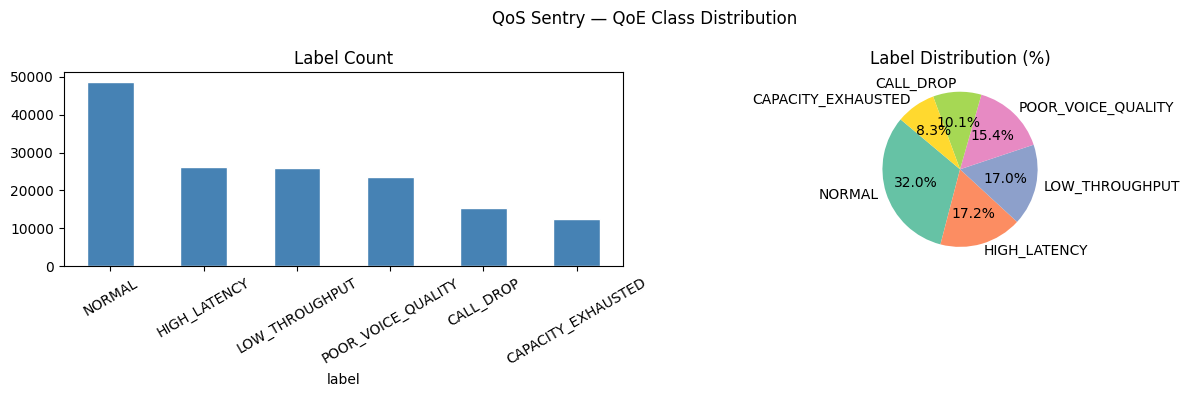

In [5]:
# ── Label distribution ────────────────────────────────────────────────────────
label_counts = df_raw['label'].value_counts()
label_pct    = label_counts / len(df_raw) * 100
print('=== QoE Label Distribution) ===')
print(pd.DataFrame({'count': label_counts, '%': label_pct.round(2)}).to_string())
print(f'\nImbalance ratio: {label_counts.max()/label_counts.min():.1f}x')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
label_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Label Count'); axes[0].tick_params(axis='x', rotation=30)
axes[1].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
            startangle=140, colors=plt.cm.Set2.colors)
axes[1].set_title('Label Distribution (%)')
plt.suptitle('QoS Sentry — QoE Class Distribution', fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
DROP_COLS = [
    'run_id', 'datetime', 'mos_source', 'switch_id',
    'rebuffering_count', 'total_stall_seconds', 'rx_dropped', 'tx_dropped',
]

SLA_FEATURES = [
    'e2e_delay_ms', 'jitter_ms', 'plr', 'throughput_mbps',
    'mos_voice', 'ctrl_plane_rtt_ms', 'availability',
]

LAG_COLS  = ['e2e_delay_ms', 'throughput_mbps', 'mos_voice', 'plr', 'jitter_ms', 'ctrl_plane_rtt_ms']
DIFF_COLS = ['e2e_delay_ms', 'throughput_mbps', 'plr', 'mos_voice']


def preprocess_segment(seg_df, train_frac, roll_w, lag_steps,
                        le=None, scaler=None, fit=True):
    df = seg_df.copy().sort_values('timestamp').reset_index(drop=True)

    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

    if 'video_start_time_ms' in df.columns:
        df['video_start_time_ms'] = df['video_start_time_ms'].clip(0, 1e8)

    if 'flow_count' in df.columns:
        df['flow_count'] = df['flow_count'].replace(0, np.nan).ffill().bfill().fillna(0)

    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)

    NUMERIC = [c for c in df.select_dtypes(include=np.number).columns
               if c not in ['port_no']]
    train_end_iqr = int(train_frac * len(df))
    Q1  = df[NUMERIC].iloc[:train_end_iqr].quantile(0.25)
    Q3  = df[NUMERIC].iloc[:train_end_iqr].quantile(0.75)
    IQR = Q3 - Q1
    df[NUMERIC] = df[NUMERIC].clip(
        lower=pd.Series((Q1 - 3*IQR).to_dict()),
        upper=pd.Series((Q3 + 3*IQR).to_dict()), axis=1
    )

    df[NUMERIC] = df[NUMERIC].interpolate(method='linear').ffill().bfill()

    if fit:
        le = LabelEncoder().fit(df['label'])
    y_all = le.transform(df['label']).astype(np.int64)


    if 'segment' in df.columns:
        df = pd.get_dummies(df, columns=['segment'], drop_first=False)

    if 'port_no' in df.columns:
        df = pd.get_dummies(df, columns=['port_no'], prefix='port', drop_first=False)

    """
    
    W = roll_w
    for col in SLA_FEATURES:
        if col in df.columns:
            df[f'{col}_rmean'] = df[col].rolling(W, min_periods=1).mean()
            df[f'{col}_rstd']  = df[col].rolling(W, min_periods=1).std().fillna(0)
            df[f'{col}_rmax']  = df[col].rolling(W, min_periods=1).max()

    for col in LAG_COLS:
        for lag in lag_steps:
            if col in df.columns:
                df[f'{col}_lag{lag}'] = df[col].shift(lag).bfill()

    for col in DIFF_COLS:
        if col in df.columns:
            df[f'{col}_diff'] = df[col].diff().fillna(0)
            df[f'{col}_diff_rmean'] = df[f'{col}_diff'].rolling(W, min_periods=1).mean()
    """
    if all(c in df.columns for c in ['mos_voice', 'plr', 'jitter_ms']):
        df['voice_pressure'] = (
            (5 - df['mos_voice'].clip(1, 5)) / 4 +
            df['plr'].clip(0, 1) +
            df['jitter_ms'].clip(0, 200) / 200
        ) / 3

    # if all(c in df.columns for c in ['throughput_mbps', 'effective_bitrate_mbps']):
    #     df['throughput_gap'] = df['effective_bitrate_mbps'] - df['throughput_mbps']

    # if all(c in df.columns for c in ['buffering_ratio', 'rebuffering_freq']):
    #     df['stream_stress'] = df['buffering_ratio'] * (df['rebuffering_freq'] + 1)

    # if 'flow_count' in df.columns:
    #     df['flow_pressure'] = np.log1p(df['flow_count'])

    df['hour']     = df['timestamp'].dt.hour
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df.drop(columns=['hour'], inplace=True)

    # After
    EXCLUDE = ['timestamp', 'label', 'label_encoded']
    feat_cols = [c for c in df.columns if c not in EXCLUDE]
    X_df      = df[feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    X_all     = X_df.values.astype(np.float32)

    train_end = int(train_frac * len(X_all))
    scaler = RobustScaler().fit(X_all[:train_end])
    X_scaled = scaler.transform(X_all)

    return X_scaled, y_all, le, scaler, feat_cols


print('✅ preprocess_segment() defined — outputs features from raw telemetry only (no label leakage).')


✅ preprocess_segment() defined — outputs features from raw telemetry only (no label leakage).


In [7]:
# ── Process ALL 4 segments ────────────────────────────────────────────────────
SEGMENTS = df_raw['segment'].unique().tolist()
print(f'Processing {len(SEGMENTS)} segments with shared LabelEncoder, per-segment RobustScaler:')

ref_seg = df_raw[df_raw['segment'] == 'INTERNET'].copy()
_, _, label_encoder, _, _ = preprocess_segment(
    ref_seg, CFG['train_frac'], CFG['roll_window'], CFG['lag_steps'], fit=True
)

seg_data = {}
for seg_name in SEGMENTS:
    seg_df = df_raw[df_raw['segment'] == seg_name].copy()
    X_sc, y, le, sc, fc = preprocess_segment(
        seg_df, CFG['train_frac'], CFG['roll_window'], CFG['lag_steps'],
        le=label_encoder, fit=False
    )
    seg_data[seg_name] = (X_sc, y, fc)
    print(f'  {seg_name}: X={X_sc.shape}, y={y.shape}')

NUM_CLASSES = len(label_encoder.classes_)
INPUT_SIZE  = seg_data[SEGMENTS[0]][0].shape[1]
feat_cols   = seg_data[SEGMENTS[0]][2]

joblib.dump(label_encoder, 'artifacts/label_encoder.pkl')
with open('artifacts/feature_columns.json', 'w') as f:
    json.dump(feat_cols, f, indent=2)

print(f'\n✅ LSTM_VF preprocessing complete.')
print(f'   Classes ({NUM_CLASSES}): {label_encoder.classes_}')
print(f'   Input size: {INPUT_SIZE} features | label_encoder.pkl + feature_columns.json saved.')

Processing 4 segments with shared LabelEncoder, per-segment RobustScaler:
  INTERNET: X=(38022, 26), y=(38022,)
  OUTDOOR_RAN: X=(38019, 26), y=(38019,)
  INDOOR_RAN: X=(38016, 26), y=(38016,)
  IMS_CDN: X=(38014, 26), y=(38014,)

✅ LSTM_VF preprocessing complete.
   Classes (6): ['CALL_DROP' 'CAPACITY_EXHAUSTED' 'HIGH_LATENCY' 'LOW_THROUGHPUT' 'NORMAL'
 'POOR_VOICE_QUALITY']
   Input size: 26 features | label_encoder.pkl + feature_columns.json saved.


In [8]:
# ── Sequence creation & time-aware split ─────────────────────────────────────

def create_sequences(X, y, window, horizon):
    Xs, ys, is_transition = [], [], []
    max_i = len(X) - window - horizon + 1
    for i in range(max_i):
        target      = y[i + window + horizon - 1]
        last_in_win = y[i + window - 1]
        Xs.append(X[i : i + window])
        ys.append(target)
        is_transition.append(target != last_in_win)
    return (
        np.array(Xs, dtype=np.float32),
        np.array(ys, dtype=np.int64),
        np.array(is_transition, dtype=bool)
    )


def time_split(X, y, mask, train_frac, val_frac):
    N = len(X)
    t = int(train_frac * N)
    v = t + int(val_frac * N)
    return (
        X[:t],  y[:t],  mask[:t],
        X[t:v], y[t:v], mask[t:v],
        X[v:],  y[v:],  mask[v:],
    )


all_Xtr, all_ytr, all_mtr = [], [], []
all_Xva, all_yva          = [], []
all_Xte, all_yte          = [], []

for seg_name, (X_sc, y, _) in seg_data.items():
    Xs, ys, masks = create_sequences(X_sc, y, CFG['window_size'], CFG['horizon'])
    Xtr, ytr, mtr, Xva, yva, mva, Xte, yte, _ = time_split(
        Xs, ys, masks, CFG['train_frac'], CFG['val_frac']
    )
    all_Xtr.append(Xtr); all_ytr.append(ytr); all_mtr.append(mtr)
    all_Xva.append(Xva); all_yva.append(yva)
    all_Xte.append(Xte); all_yte.append(yte)

datasets = dict(
    X_train    = np.concatenate(all_Xtr),
    y_train    = np.concatenate(all_ytr),
    mask_train = np.concatenate(all_mtr),
    X_val      = np.concatenate(all_Xva),
    y_val      = np.concatenate(all_yva),
    X_test     = np.concatenate(all_Xte),
    y_test     = np.concatenate(all_yte),
)

n_trans = datasets['mask_train'].sum()
n_total = len(datasets['y_train'])

print(f'h=t+{CFG["horizon"]} → train={datasets["X_train"].shape} | '
        f'transition seqs={n_trans} ({n_trans/n_total*100:.1f}%) '
        f'[oversampled {CFG["transition_oversample"]}x in loader] | '
        f'val={datasets["X_val"].shape} | test={datasets["X_test"].shape}')

h=t+5 → train=(106269, 60, 26) | transition seqs=14040 (13.2%) [oversampled 6x in loader] | val=(22770, 60, 26) | test=(22776, 60, 26)


In [9]:
def make_loader(X, y, mask=None, shuffle=False,
                oversample_transitions=False, oversample_factor=None):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    
    if oversample_transitions and mask is not None:
        if oversample_factor is None:
            oversample_factor = CFG['transition_oversample']  # ← Use CFG directly
        
        weights = np.where(mask, float(oversample_factor), 1.0)
        sampler = WeightedRandomSampler(
            weights=torch.tensor(weights, dtype=torch.float32),
            num_samples=len(weights),
            replacement=True
        )
        return DataLoader(ds, batch_size=CFG['batch_size'], sampler=sampler)
    
    return DataLoader(ds, batch_size=CFG['batch_size'], shuffle=shuffle)


# CrossEntropy treats all wrong predictions equally.
# Focal Loss down-weights easy correct predictions and focuses on hard ones,
# which stops the model from memorising easy majority-class patterns.
class FocalLoss(nn.Module):
    """
    Focal Loss: FL(pt) = -alpha_t * (1-pt)^gamma * log(pt)
    - gamma=0 → standard cross-entropy
    - gamma=2 → standard focal (Lin et al. 2017)
    - gamma=3 → stronger focus on hard examples (used for t+5)
    """
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.weight          = weight
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce   = F.cross_entropy(
            logits, targets,
            weight          = self.weight,
            label_smoothing = self.label_smoothing,
            reduction       = 'none'
        )
        pt   = torch.exp(-ce)                    # probability of correct class
        loss = ((1 - pt) ** self.gamma) * ce     # down-weight easy examples
        return loss.mean()


# ── Class Weights (Single Horizon) ────────────────────────────────────────────
y_train_ref = datasets['y_train']  # ← Fixed: datasets['y_train']
base_weights = compute_class_weight(
    'balanced', classes=np.arange(NUM_CLASSES), y=y_train_ref
)

print('=== LSTM_VF Class Weights (balanced base × minority_boost) ===')
print(dict(zip(label_encoder.classes_, np.round(base_weights, 3))))

# Weight caps — classes to scale DOWN
WEIGHT_CAPS = {
    'HIGH_LATENCY': 0.8,  # ← Simplified: no horizon key
}

# Apply minority boost and weight caps
CLASS_WEIGHTS = base_weights.copy()

# Boost minority classes
for cls in CFG['minority_boost_classes']:
    if cls in label_encoder.classes_:
        idx = int(np.where(label_encoder.classes_ == cls)[0])
        CLASS_WEIGHTS[idx] *= CFG['minority_boost']  # ← Use CFG directly

# Cap over-dominant classes
for cls, scale in WEIGHT_CAPS.items():
    if cls in label_encoder.classes_:
        idx = int(np.where(label_encoder.classes_ == cls)[0])
        CLASS_WEIGHTS[idx] *= scale

CLASS_WEIGHTS = torch.tensor(CLASS_WEIGHTS, dtype=torch.float32).to(DEVICE)

print(f'  (boost={CFG["minority_boost"]}x): '
      f'CALL_DROP={CLASS_WEIGHTS[label_encoder.transform(["CALL_DROP"])[0]]:.2f}, '
      f'CAPACITY_EXHAUSTED={CLASS_WEIGHTS[label_encoder.transform(["CAPACITY_EXHAUSTED"])[0]]:.2f}, '
      f'HIGH_LATENCY={CLASS_WEIGHTS[label_encoder.transform(["HIGH_LATENCY"])[0]]:.2f}')

=== LSTM_VF Class Weights (balanced base × minority_boost) ===
{'CALL_DROP': np.float64(1.679), 'CAPACITY_EXHAUSTED': np.float64(1.877), 'HIGH_LATENCY': np.float64(0.96), 'LOW_THROUGHPUT': np.float64(1.076), 'NORMAL': np.float64(0.515), 'POOR_VOICE_QUALITY': np.float64(1.042)}
  (boost=1.0x): CALL_DROP=1.68, CAPACITY_EXHAUSTED=1.88, HIGH_LATENCY=0.77


In [10]:
class LSTMForecaster(nn.Module):
    """Unidirectional LSTM for future QoE class forecasting."""
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False,
        )
        self.norm = nn.LayerNorm(hidden_size)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_classes),
        )
    
    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.classifier(self.norm(last))


class TemporalAttention(nn.Module):
    """Calculates a weighted average of all time steps in the LSTM output."""
    def __init__(self, hidden_size):
        super().__init__()
        # A small neural network to score how "important" each time step is
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1)
        )

    def forward(self, lstm_out):
        # lstm_out shape: (Batch, SeqLen, Hidden)
        
        # 1. Calculate raw attention scores for each step
        attn_scores = self.attention(lstm_out)  # Shape: (Batch, SeqLen, 1)
        
        # 2. Convert scores to probabilities (weights) using softmax
        attn_weights = F.softmax(attn_scores, dim=1) 
        
        # 3. Multiply the LSTM outputs by their weights and sum them up
        # This creates a single context vector that focuses on the important time steps
        context = torch.sum(attn_weights * lstm_out, dim=1)  # Shape: (Batch, Hidden)
        
        return context, attn_weights


class LSTMAttentionForecaster(nn.Module):
    """LSTM with Temporal Attention and optional Bidirectional processing."""
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout, bidirectional=False):
        super().__init__()
        
        # If bidirectional, we halve the hidden size per direction so the 
        # final concatenated output still matches the requested `hidden_size`
        lstm_hidden = hidden_size // 2 if bidirectional else hidden_size
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=lstm_hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        
        self.attention = TemporalAttention(hidden_size)
        self.norm = nn.LayerNorm(hidden_size)
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_classes),
        )
    
    def forward(self, x):
        # 1. Pass through LSTM
        out, _ = self.lstm(x)  # out is (Batch, SeqLen, Hidden)
        
        # 2. Apply Attention instead of just grabbing the last step
        context, attn_weights = self.attention(out)
        
        # 3. Classify
        return self.classifier(self.norm(context))
        
        
class QueryAttention(nn.Module):
    """
    Query-based Attention. Uses the final LSTM state (the present) 
    to decide which past steps to focus on.
    """
    def __init__(self, hidden_size):
        super().__init__()
        self.seq_proj = nn.Linear(hidden_size, hidden_size, bias=False)
        self.query_proj = nn.Linear(hidden_size, hidden_size, bias=False)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, lstm_out, last_state):
        # lstm_out: (Batch, SeqLen, Hidden)
        # last_state: (Batch, Hidden)
        
        # Add a sequence dimension to the last state so we can add them
        last_state_expanded = last_state.unsqueeze(1) # (Batch, 1, Hidden)
        
        # Score = V * tanh( W1*Sequence + W2*Last_State )
        # This compares every past step against the current present state
        energy = torch.tanh(self.seq_proj(lstm_out) + self.query_proj(last_state_expanded))
        scores = self.v(energy) # (Batch, SeqLen, 1)
        
        # Convert to weights
        attn_weights = F.softmax(scores, dim=1)
        
        # Weighted sum of the sequence
        context = torch.sum(attn_weights * lstm_out, dim=1) # (Batch, Hidden)
        return context, attn_weights

class LSTMQueryAttentionForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False # Strictly forward-only
        )
        
        self.attention = QueryAttention(hidden_size)
        self.norm = nn.LayerNorm(hidden_size * 2) # We concatenate Context + Last State
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, num_classes),
        )
    
    def forward(self, x):
        # 1. Pass through LSTM
        out, _ = self.lstm(x)
        
        # 2. Extract the very last step (the present)
        last_state = out[:, -1, :] 
        
        # 3. Use the last state to query the past
        context, attn_weights = self.attention(out, last_state)
        
        # 4. Concatenate the present (last_state) with the summarized past (context)
        # This guarantees the model never loses track of what is happening RIGHT NOW
        combined = torch.cat([context, last_state], dim=1)
        
        # 5. Classify
        return self.classifier(self.norm(combined))

In [11]:
class EarlyStopping:
    """
    Monitor val MACRO F1 (maximise) — not val loss.
    Val loss is distorted by transition oversampling in the train loader.
    Val F1 on the unweighted val set is the correct signal.
    """
    def __init__(self, patience, path):
        self.patience = patience
        self.path     = path
        self.best     = -np.inf
        self.counter  = 0
        self.stop     = False

    def __call__(self, val_f1, model):
        if val_f1 > self.best + 1e-4:
            self.best    = val_f1
            self.counter = 0
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def run_epoch(model, loader, criterion, optimizer=None, train=True, clip_grad=0.5):
    model.train() if train else model.eval()
    total_loss, preds, labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss   = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                # FIX D: tighter gradient clipping (was 1.0)
                nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
                optimizer.step()
            total_loss += loss.item() * len(yb)
            preds.extend(logits.argmax(1).cpu().numpy())
            labels.extend(yb.cpu().numpy())
    p, l = np.array(preds), np.array(labels)
    return (
        total_loss / len(loader.dataset),
        accuracy_score(l, p),
        f1_score(l, p, average='macro', zero_division=0),
    )


def train_lstm():
    """Train LSTM for QoE forecasting (single horizon)."""
    
    # Create model directly
    model = LSTMForecaster(
        input_size=INPUT_SIZE,
        hidden_size=CFG['hidden_size'],
        num_layers=CFG['num_layers'],
        num_classes=NUM_CLASSES,
        dropout=CFG['dropout'],
    ).to(DEVICE)
    
    # Focal Loss with class weights
    # criterion = FocalLoss(
    #     weight=CLASS_WEIGHTS,  # ← Single tensor
    #     gamma=CFG['focal_gamma'],
    #     label_smoothing=CFG['label_smoothing'],
    # )
    
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS,
                                    label_smoothing=CFG['label_smoothing']
                                    )
    
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CFG['lr'],
        weight_decay=CFG['weight_decay'],
    )
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )
    
    # Data loaders
    train_loader = make_loader(
        datasets['X_train'], datasets['y_train'],
        mask=datasets['mask_train'],
        oversample_transitions=True,
    )
    val_loader = make_loader(datasets['X_val'], datasets['y_val'])
    
    # Early stopping
    save_path = 'artifacts/best_lstm_vf.pt'  # ← Simplified
    es = EarlyStopping(CFG['patience'], save_path)
    
    history = {k: [] for k in 
               ['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1']}
    
    print(f'\n{chr(8212)*68}')
    print(f'  LSTM_VF | horizon=t+{CFG["horizon"]} (~{CFG["horizon"]*2}s ahead)')
    print(f'  lr={CFG["lr"]} | hidden={CFG["hidden_size"]} | '
          f'layers={CFG["num_layers"]} | dropout={CFG["dropout"]}')
    print(f'  patience={CFG["patience"]} | oversample={CFG["transition_oversample"]}× | '
          f'boost={CFG["minority_boost"]}× | focal_gamma={CFG["focal_gamma"]}')
    print(f'{chr(8212)*68}')
    print(f'  {"Ep":>4}  {"T-loss":>7}  {"T-acc":>6}  {"T-F1":>6}  '
          f'{"V-loss":>7}  {"V-acc":>6}  {"V-F1":>6}  {"LR":>8}')
    print(f'  {"-"*70}')
    
    t0 = time.time()
    for epoch in range(1, CFG['max_epochs'] + 1):
        tl, ta, tf = run_epoch(model, train_loader, criterion, optimizer,
                               train=True, clip_grad=CFG['clip_grad'])
        vl, va, vf = run_epoch(model, val_loader, criterion,
                               train=False, clip_grad=CFG['clip_grad'])
        
        scheduler.step(vf)
        es(vf, model)
        
        current_lr = optimizer.param_groups[0]['lr']
        
        for k, v in zip(
            ['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1'],
            [tl, vl, ta, va, tf, vf]
        ):
            history[k].append(v)
        
        if epoch % 5 == 0 or es.stop or epoch == 1:
            best_mark = ' <- best' if vf >= es.best - 1e-4 else ''
            print(f'  {epoch:4d}  {tl:7.4f}  {ta:6.3f}  {tf:6.3f}  '
                  f'{vl:7.4f}  {va:6.3f}  {vf:6.3f}  {current_lr:8.2e}{best_mark}')
        
        if es.stop:
            print(f'\n  ⏹ Early stop ep={epoch} | best val F1={es.best:.4f}')
            break
    
    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    print(f'  ✅ LSTM_VF h=t+{CFG["horizon"]} — done in {time.time()-t0:.1f}s | best checkpoint reloaded.')
    
    return model, history


print('✅ Training functions defined (LSTM_VF).')
print('   EarlyStopping: val Macro F1 (maximise) — immune to oversampling distortion.')
print('   Optimizer: AdamW | Scheduler: ReduceLROnPlateau(factor=0.5, patience=3) on val F1.')
print('   Gradient clipping: clip_grad_norm per horizon (0.5).')

✅ Training functions defined (LSTM_VF).
   EarlyStopping: val Macro F1 (maximise) — immune to oversampling distortion.
   Optimizer: AdamW | Scheduler: ReduceLROnPlateau(factor=0.5, patience=3) on val F1.
   Gradient clipping: clip_grad_norm per horizon (0.5).


In [12]:
import optuna
def objective(trial):
    # 1. Define the Hyperparameter Search Space
    hidden_size  = trial.suggest_categorical('hidden_size', [128, 256, 512])
    num_layers   = trial.suggest_int('num_layers', 1, 4)
    dropout      = trial.suggest_float('dropout', 0.1, 0.5)
    lr           = trial.suggest_float('lr', 1e-5, 2e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    oversample = trial.suggest_int('transition_oversample', 2, 6, 12)   
    use_bilstm    = trial.suggest_categorical('bidirectional', [True, False])
    # 2. Build the Model
    model = LSTMQueryAttentionForecaster(
        input_size=INPUT_SIZE,
        hidden_size=hidden_size,
        num_layers=num_layers,
        num_classes=NUM_CLASSES,
        dropout=dropout,
        #bidirectional=use_bilstm
    ).to(DEVICE)
    
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS, label_smoothing=CFG['label_smoothing'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # 3. Create Loaders with Trial's Oversample Factor
    train_loader = make_loader(
        datasets['X_train'], datasets['y_train'],
        mask=datasets['mask_train'],
        oversample_transitions=True,
        oversample_factor=oversample
    )
    val_loader = make_loader(datasets['X_val'], datasets['y_val'])
    
    # 4. Fast Training Loop (15 Epochs to evaluate potential)
    for epoch in range(1, 16):
        # Train
        run_epoch(model, train_loader, criterion, optimizer, train=True, clip_grad=CFG['clip_grad'])
        
        # Evaluate
        _, _, val_f1 = run_epoch(model, val_loader, criterion, train=False, clip_grad=CFG['clip_grad'])
        
        # Report progress to Optuna
        trial.report(val_f1, epoch)
        
        # Prune (stop early) if the trial is performing badly compared to others
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    return val_f1

print("\n🚀 Starting Optuna Hyperparameter Search...")
# # Create a study to maximize Validation Macro F1
# study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
# study.optimize(objective, n_trials=50)  # ← Change n_trials to 30 or 50 if you have time

# print("\n✅ Optuna Search Complete!")
# print(f"  Best Val F1: {study.best_value:.4f}")
# print("  Best Hyperparameters:")
# for key, value in study.best_params.items():
#     print(f"    {key}: {value}")
#     CFG[key] = value  # Automatically update your CFG with the winning params!


study = optuna.create_study(
    study_name="qoe_lstm_study",
    storage="sqlite:///optuna_qoe.db", # Saves progress to disk!
    load_if_exists=True,               # Resumes if you stop and restart
    direction="maximize", 
    pruner=optuna.pruners.MedianPruner()
)

# 2. Run with n_jobs to utilize your GPU in parallel
# Set n_jobs to 4, 8, or whatever your CPU can comfortably handle.
study.optimize(objective, n_trials=50, n_jobs=8)  

print("\n✅ Optuna Search Complete!")
print(f"  Best Val F1: {study.best_value:.4f}")
print("  Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")
    CFG[key] = value


🚀 Starting Optuna Hyperparameter Search...


[I 2026-04-10 21:54:57,267] A new study created in RDB with name: qoe_lstm_study
[I 2026-04-10 21:56:59,168] Trial 3 finished with value: 0.5249565755357061 and parameters: {'hidden_size': 128, 'num_layers': 1, 'dropout': 0.1113460929595537, 'lr': 0.0001428294698286312, 'weight_decay': 2.1573676983523515e-05, 'transition_oversample': 2, 'bidirectional': False}. Best is trial 3 with value: 0.5249565755357061.
[I 2026-04-10 21:57:04,699] Trial 6 finished with value: 0.5990727825285743 and parameters: {'hidden_size': 128, 'num_layers': 3, 'dropout': 0.4578972941602528, 'lr': 8.278234205852108e-05, 'weight_decay': 1.0631564031866733e-05, 'transition_oversample': 2, 'bidirectional': False}. Best is trial 6 with value: 0.5990727825285743.
[I 2026-04-10 21:58:12,920] Trial 5 finished with value: 0.5260533232030536 and parameters: {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.13162445212310564, 'lr': 5.035594012593045e-05, 'weight_decay': 0.0028952697400411384, 'transition_oversample': 2,


✅ Optuna Search Complete!
  Best Val F1: 0.6959
  Best Hyperparameters:
    hidden_size: 512
    num_layers: 4
    dropout: 0.2537361551193632
    lr: 0.0007919460702296208
    weight_decay: 0.0003650555178730392
    transition_oversample: 2
    bidirectional: True


In [13]:
model, history = train_lstm()  # ← Single call!


————————————————————————————————————————————————————————————————————
  LSTM_VF | horizon=t+5 (~10s ahead)
  lr=0.0007919460702296208 | hidden=512 | layers=4 | dropout=0.2537361551193632
  patience=12 | oversample=2× | boost=1.0× | focal_gamma=1.5
————————————————————————————————————————————————————————————————————
    Ep   T-loss   T-acc    T-F1   V-loss   V-acc    V-F1        LR
  ----------------------------------------------------------------------
     1   1.7405   0.595   0.589   1.7668   0.636   0.638  7.92e-04 <- best
     5   1.6647   0.731   0.716   1.7802   0.641   0.638  7.92e-04
    10   1.5676   0.912   0.905   1.8278   0.665   0.654  7.92e-04
    15   1.5307   0.973   0.971   1.8457   0.671   0.661  3.96e-04
    18   1.5250   0.980   0.978   1.8559   0.654   0.648  1.98e-04

  ⏹ Early stop ep=18 | best val F1=0.6867
  ✅ LSTM_VF h=t+5 — done in 121.8s | best checkpoint reloaded.


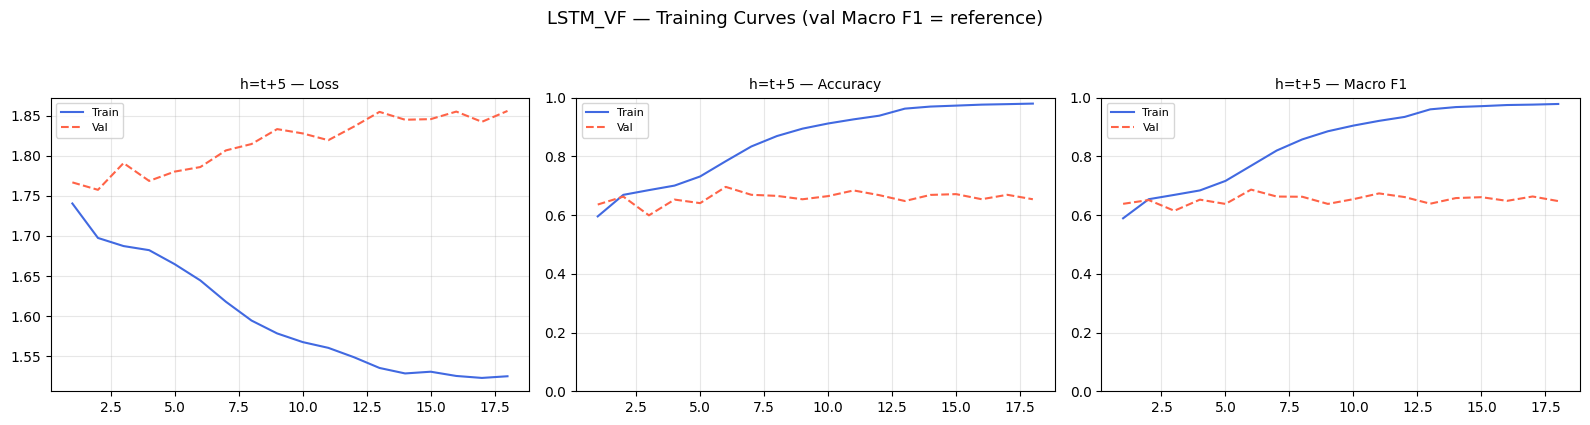

In [14]:
# ── Training curves ───────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4))  # ← Fixed: Just 1 row now!
ep = range(1, len(history['train_loss']) + 1)

for col, (tr_k, va_k, title) in enumerate([
        ('train_loss', 'val_loss', 'Loss'),
        ('train_acc',  'val_acc',  'Accuracy'),
        ('train_f1',   'val_f1',   'Macro F1'),
    ]):
    ax = axes[col]  # ← Fixed: 1D array of axes
    ax.plot(ep, history[tr_k], label='Train', color='royalblue', lw=1.5)
    ax.plot(ep, history[va_k], label='Val',   color='tomato', ls='--', lw=1.5)
    ax.set_title(f'h=t+{CFG["horizon"]} — {title}', fontsize=10)
    ax.legend(fontsize=8)
    if 'loss' not in tr_k:
        ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

plt.suptitle('LSTM_VF — Training Curves (val Macro F1 = reference)', fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig('artifacts/lstm_vf_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── Evaluation ────────────────────────────────────────────────────────────────

def evaluate(model):  # ← Fixed: Removed horizon param
    test_loader = make_loader(datasets['X_test'], datasets['y_test'])  # ← Fixed: Direct dataset access
    model.eval()
    all_preds, all_labels = [], []
    
    t0 = time.time()
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb.to(DEVICE))
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(yb.numpy())
            
    lat = (time.time() - t0) / len(all_preds) * 1000
    p, l = np.array(all_preds), np.array(all_labels)
    
    return dict(
        preds       = p,
        labels      = l,
        acc         = accuracy_score(l, p),
        macro_f1    = f1_score(l, p, average='macro',    zero_division=0),
        weighted_f1 = f1_score(l, p, average='weighted', zero_division=0),
        report      = classification_report(l, p, target_names=label_encoder.classes_, zero_division=0),
        latency_ms  = lat,
    )

# Run evaluation once!
r = evaluate(model)
h = CFG['horizon']

print(f'\n{"="*60}')
print(f'  LSTM_VF | h=t+{h} (~{h*2}s ahead)')
print(f'  Accuracy   : {r["acc"]:.4f}')
print(f'  Macro F1   : {r["macro_f1"]:.4f}')
print(f'  Weighted F1: {r["weighted_f1"]:.4f}')
print(f'  Latency    : {r["latency_ms"]:.4f} ms/sample')
print(f'{"="*60}')
print(r['report'])


  LSTM_VF | h=t+5 (~10s ahead)
  Accuracy   : 0.6718
  Macro F1   : 0.6810
  Weighted F1: 0.6752
  Latency    : 0.0175 ms/sample
                    precision    recall  f1-score   support

         CALL_DROP       0.55      0.84      0.66      2779
CAPACITY_EXHAUSTED       0.59      0.88      0.71      1544
      HIGH_LATENCY       0.89      0.61      0.72      3684
    LOW_THROUGHPUT       0.88      0.63      0.73      4279
            NORMAL       0.71      0.58      0.64      7036
POOR_VOICE_QUALITY       0.53      0.75      0.62      3454

          accuracy                           0.67     22776
         macro avg       0.69      0.71      0.68     22776
      weighted avg       0.72      0.67      0.68     22776



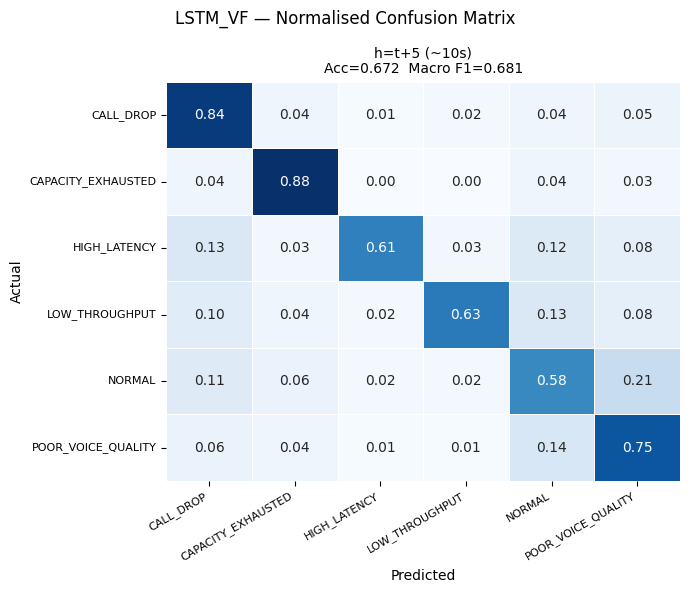

In [16]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 6))  # ← Fixed: Single plot, no subplots loop
cm = confusion_matrix(r['labels'], r['preds'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(np.round(cm_norm, 2), ax=ax, annot=True, fmt='.2f',
            cmap='Blues', linewidths=0.4, cbar=False,
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

ax.set_title(f'h=t+{h} (~{h*2}s)\nAcc={r["acc"]:.3f}  Macro F1={r["macro_f1"]:.3f}', fontsize=10)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_xticklabels(label_encoder.classes_, rotation=30, ha='right', fontsize=8)
ax.set_yticklabels(label_encoder.classes_, rotation=0, fontsize=8)

plt.suptitle('LSTM_VF — Normalised Confusion Matrix', fontsize=12)
plt.tight_layout()
plt.savefig('artifacts/lstm_vf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

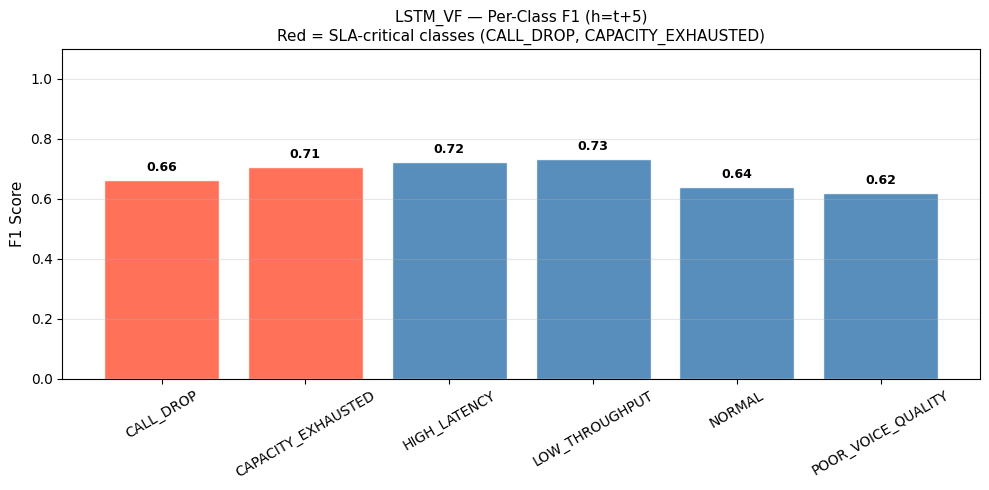

In [17]:
# ── Per-class F1 Bar Chart ──────────────────────────────────────────────────

pc_f1 = f1_score(r['labels'], r['preds'], average=None, 
                 zero_division=0, labels=np.arange(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(10, 5))

# Color minority classes RED, normal classes BLUE
colors = ['tomato' if cls in CFG['minority_boost_classes'] else 'steelblue' 
          for cls in label_encoder.classes_]

bars = ax.bar(label_encoder.classes_, pc_f1, color=colors, edgecolor='white', alpha=0.9)

ax.set_ylabel('F1 Score', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title(f'LSTM_VF — Per-Class F1 (h=t+{h})\nRed = SLA-critical classes (CALL_DROP, CAPACITY_EXHAUSTED)', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)

# Add numeric labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('artifacts/lstm_vf_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()